<a href="https://colab.research.google.com/github/peremartra/optipfair/blob/main/examples/knowledge_distillation_express.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OptiPFair Notebook Series - Example: Knowledge Distillation Express
![optiPfair Logo](https://github.com/peremartra/optipfair/blob/main/images/optiPfair.png?raw=true)
This notebook demonstrates how to use [OptiPFair](https://github.com/peremartra/optipfair) to recover performance after depth pruning using knowledge distillation.
It follows a compact workflow with public APIs only: load teacher and student models, create a depth-pruned student, distill knowledge, and run lm_eval benchmarks.

## Recommended Environment
- **Platform**: [Google Colab](https://colab.research.google.com)
- **Hardware**: GPU A100 (or T4 for smaller models)
- **Dependencies**: Installed in Section 0

## by Pere Martra
- [LinkedIn](https://www.linkedin.com/in/pere-martra)
- [GitHub](https://github.com/peremartra)
- [X / Twitter](https://x.com/peremartra)

---
> If you find this useful, please star the [repository](https://github.com/peremartra/optipfair).
---
If you want your favorite LLM to create code with optipfair, provide [optipfair_llm_reference_manual.txt](https://github.com/peremartra/optipfair/blob/main/optipfair_llm_reference_manual.txt).

## 0. Environment and Dependencies

In [ ]:
!pip install --upgrade git+https://github.com/peremartra/optipfair.git
#!pip install -q optipfair==0.4.0
!pip install -q transformers==5.4.0
!pip install -q datasets tqdm matplotlib
!pip install -q lm-eval langdetect codecarbon
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

## 1. Global Configuration

In [2]:
# Models
TEACHER_MODEL_ID = "meta-llama/Llama-3.2-3B"
STUDENT_MODEL_ID = "oopere/llama-3.2-3b-attn-drop-3"

# Data and training
DATASET_NAME = "HuggingFaceTB/cosmopedia"
RECOVERY_SAMPLES = 10000
EPOCHS = 2
LEARNING_RATE = 2.5e-5
BATCH_SIZE = 6
MAX_LENGTH = 512
LAYERS_TO_REMOVE_COUNT = 10

# Distillation config
ALPHA = 0.55
BETA = 0.35
GAMMA = 0.01
DELTA = 0.05
TEMPERATURE = 2
SKEW_ALPHA = 0.3
SCHEDULER = "cosine"
WARMUP_RATIO = 0.15
ACCUMULATION_STEPS = 6
LAYER_MAPPING_STRATEGY = "last"

# lm_eval defaults
BENCHMARK_TASKS = [
    "arc_easy",
    "winogrande",
    "hellaswag",
    "lambada_openai",
    "piqa",
]
LIMIT_BENCHMARK = 400
LMEVAL_BATCH_SIZE = "auto"

SUBSETS = [
    ("stories", 0.300),
    ("web_samples_v2", 0.200),
    ("web_samples_v1", 0.150),
    ("wikihow", 0.150),
    ("openstax", 0.125),
    ("stanford", 0.075),
]

## 2. Imports and Setup

In [3]:
import torch
import matplotlib.pyplot as plt
from copy import deepcopy
from datasets import Dataset, load_dataset
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import optipfair as opf
from utils import model_evaluation, get_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
assert abs(sum(w for _, w in SUBSETS) - 1.0) < 1e-6

Using device: cuda


In [ ]:
print(f"Loading teacher model: {TEACHER_MODEL_ID}")
teacher_model = AutoModelForCausalLM.from_pretrained(
    TEACHER_MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
teacher_model.eval()
for p in teacher_model.parameters():
    p.requires_grad = False

In [ ]:
print(f"Loading student base model: {STUDENT_MODEL_ID}")
student_model = AutoModelForCausalLM.from_pretrained(
    STUDENT_MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Teacher layers: {teacher_model.config.num_hidden_layers}")
print(f"Student base layers: {student_model.config.num_hidden_layers}")

## 3. Prepare Recovery Dataset

In [ ]:
print("Loading Cosmopedia subsets...")
all_samples = []
for subset, weight in SUBSETS:
    n_samples = int(RECOVERY_SAMPLES * weight)
    subset_data = load_dataset(DATASET_NAME, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(n_samples))
    all_samples.extend(subset_samples)

distillation_dataset = Dataset.from_dict({"text": [s["text"] for s in all_samples]})
print(f"Total samples: {len(distillation_dataset):,}")

texts = [item["text"] for item in distillation_dataset]
tokenized_batches = []
for i in tqdm(range(0, len(texts), 100), desc="Tokenizing"):
    batch = tokenizer(
        texts[i:i + 100],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    tokenized_batches.append(batch)

input_ids = torch.cat([b["input_ids"] for b in tokenized_batches], dim=0)
attention_mask = torch.cat([b["attention_mask"] for b in tokenized_batches], dim=0)
full_dataset = TensorDataset(input_ids, attention_mask)

generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Train: {len(train_dataset):,} samples ({len(train_dataloader):,} batches)")
print(f"Val: {len(val_dataset):,} samples")

## 5. Knowledge Distillation

In [ ]:
student_to_train = deepcopy(student_model)

trained_student, stats = opf.distill_model(
    student_model=student_to_train,
    teacher_model=teacher_model,
    dataloader=train_dataloader,
    alpha=ALPHA,
    beta=BETA,
    gamma=GAMMA,
    delta=DELTA,
    temperature=TEMPERATURE,
    skew_alpha=SKEW_ALPHA,
    scheduler=SCHEDULER,
    warmup_ratio=WARMUP_RATIO,
    layer_mapping_strategy=LAYER_MAPPING_STRATEGY,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    accumulation_steps=ACCUMULATION_STEPS,
    show_progress=True,
    return_stats=True,
)

print("Training complete")
print(f"Total time: {stats['total_time_seconds']:.1f}s ({stats['total_time_seconds'] / 60:.1f} min)")
print(f"Final total loss: {stats['loss_history']['total'][-1]:.4f}")

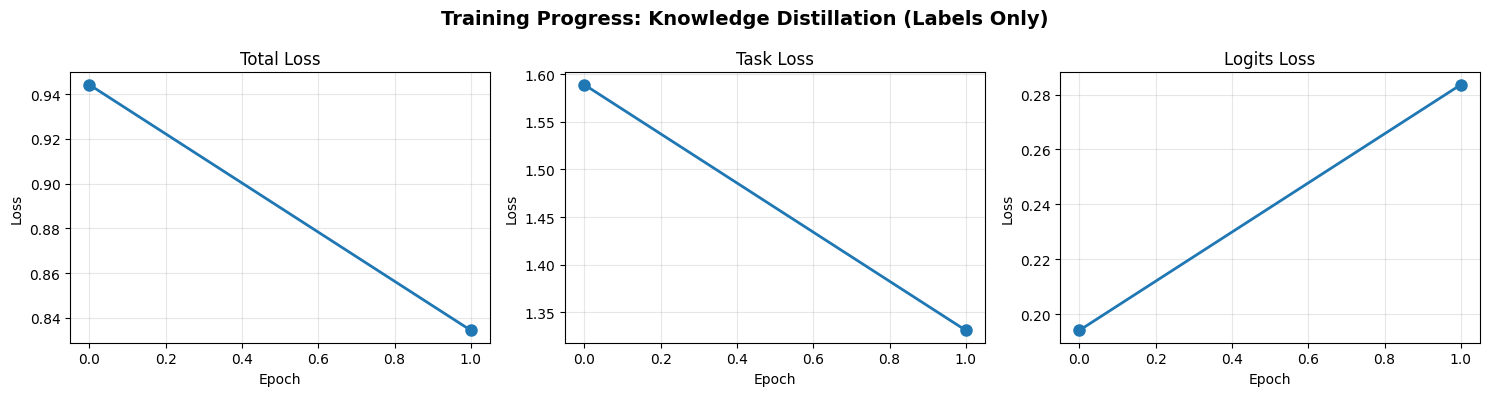

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
loss_keys = [("total", "Total Loss"), ("task", "Task Loss"), ("logits", "Logits Loss")]
for idx, (key, title) in enumerate(loss_keys):
    axes[idx].plot(stats['loss_history'][key], marker='o', linewidth=2, markersize=8)
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('Training Progress: Knowledge Distillation (Labels Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Final lm_eval Benchmarks

In [ ]:
trained_student.eval()
print("Running lm_eval benchmarks...")
print(f"Tasks: {BENCHMARK_TASKS}")
print(f"Rows per task (limit): {LIMIT_BENCHMARK}")
print(f"Batch size: {LMEVAL_BATCH_SIZE}")

student_bench_raw = model_evaluation(
    trained_student,
    tokenizer,
    BENCHMARK_TASKS,
    limit=LIMIT_BENCHMARK,
    device=str(device),
    batch_size=LMEVAL_BATCH_SIZE,
)

def extract_acc(results, task):
    r = results.get(task, {})
    for key in ("accuracy", "acc_norm", "acc"):
        if key in r:
            return float(r[key]) * 100
    return 0.0

student_scores = {task: extract_acc(student_bench_raw, task) for task in BENCHMARK_TASKS}

print("\nBenchmark results (student):")
print(f"{'Task':<20} {'Score':>10}")
print('-' * 32)
for task in BENCHMARK_TASKS:
    print(f"{task:<20} {student_scores[task]:>9.1f}%")

avg_student = sum(student_scores.values()) / len(student_scores)
print('-' * 32)
print(f"{'AVERAGE':<20} {avg_student:>9.1f}%")

In [10]:
student_bench_raw

{'arc_easy': {'accuracy': '0.7425', 'acc_norm': '0.7000'},
 'winogrande': {'accuracy': '0.6900'},
 'hellaswag': {'accuracy': '0.4975', 'acc_norm': '0.6525'},
 'lambada_openai': {'perplexity': '5.34', 'accuracy': '0.6350'},
 'piqa': {'accuracy': '0.7600', 'acc_norm': '0.7850'}}

{'arc_easy': {'accuracy': '0.7500', 'acc_norm': '0.6975'},
 'hellaswag': {'accuracy': '0.5000', 'acc_norm': '0.6525'},
 'lambada_openai': {'perplexity': '5.27', 'accuracy': '0.6425'},
 'piqa': {'accuracy': '0.7625', 'acc_norm': '0.7775'},
 'winogrande': {'accuracy': '0.6900'}}

In [11]:
BASELINE_PROMPT = "Paris is the capital of"
output = get_output(trained_student, tokenizer, BASELINE_PROMPT)
print(f"Pruned model output:\n{output}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Pruned model output:
 France and the largest city in the country. It is also one of the most popular tourist destinations in the world, attracting millions of visitors each year. The city is known for its rich history, beautiful architecture, and vibrant culture. There are many things to see and do in Paris, but one of the most popular activities is visiting the Eiffel Tower. The tower was built for the World's Fair in 1889 and has since become an iconic symbol of Paris. The Eiffel Tower
